## Hospital Equipment Intelligence Dashboard

In [8]:
import pandas as pd   #importing packages
import numpy as np

In [9]:
np.random.seed(42)     ##Data Generating

n = 500

df = pd.DataFrame({
    "equipment_id": range(1, n+1),
    "equipment_type": np.random.choice(["Ventilator", "MRI", "X-Ray"], n),
    "usage_hours": np.random.randint(50, 500, n),
    "days_since_maintenance": np.random.randint(1, 100, n),
    "temperature": np.random.uniform(20, 80, n),
    "load": np.random.uniform(0.1, 1.0, n)
})

In [10]:
## Creating pattern-based failures, not random chaos
df["failure"] = (  
    (df["usage_hours"] > 400) |
    (df["days_since_maintenance"] > 70) |
    (df["temperature"] > 60)
).astype(int)

In [11]:
## Adding Imperfection to get some missed values, becoz real data is not always clean
df.loc[df.sample(frac=0.05).index, 'temperature'] = np.nan

In [12]:
## Saving Dataset
df.to_csv("hospital_equipment_data.csv", index=False)

In [14]:
df.head()

,equipment_id,equipment_type,usage_hours,days_since_maintenance,temperature,load,failure
0,1,X-Ray,443,14,35.043840,0.115764,1
1,2,Ventilator,299,59,57.985884,0.319733,0
2,3,X-Ray,196,56,49.656431,0.847789,0
3,4,X-Ray,491,7,54.397663,0.878148,1
4,5,Ventilator,145,3,70.286418,0.791667,1


In [15]:
df.info() #Information of the Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   equipment_id            500 non-null    int64  
 1   equipment_type          500 non-null    object 
 2   usage_hours             500 non-null    int32  
 3   days_since_maintenance  500 non-null    int32  
 4   temperature             475 non-null    float64
 5   load                    500 non-null    float64
 6   failure                 500 non-null    int64  
dtypes: float64(2), int32(2), int64(2), object(1)
memory usage: 23.6+ KB


In [16]:
df.describe()

,equipment_id,usage_hours,days_since_maintenance,temperature,load,failure
count,500.000000,500.000000,500.000000,475.000000,500.000000,500.000000
mean,250.500000,274.696000,48.232000,49.942011,0.544332,0.606000
std,144.481833,130.150489,28.831036,17.535320,0.253165,0.489124
min,1.000000,50.000000,1.000000,20.014251,0.100299,0.000000
25%,125.750000,165.500000,24.000000,34.519267,0.319251,0.000000
50%,250.500000,272.500000,47.000000,50.964741,0.555826,1.000000
75%,375.250000,390.250000,72.250000,64.628957,0.768355,1.000000
max,500.000000,499.000000,99.000000,79.961210,0.995932,1.000000


In [17]:
df.isnull().sum()  #Cleaning the Data

equipment_id               0
equipment_type             0
usage_hours                0
days_since_maintenance     0
temperature               25
load                       0
failure                    0
dtype: int64

<Axes: title={'center': 'Failure Count'}, xlabel='failure'>

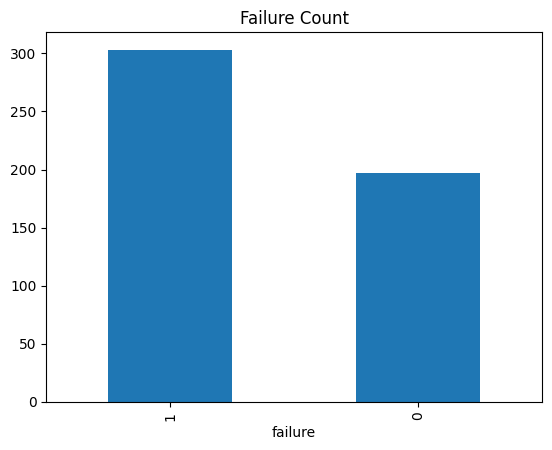

In [19]:
df['failure'].value_counts().plot(kind='bar', title="Failure Count")

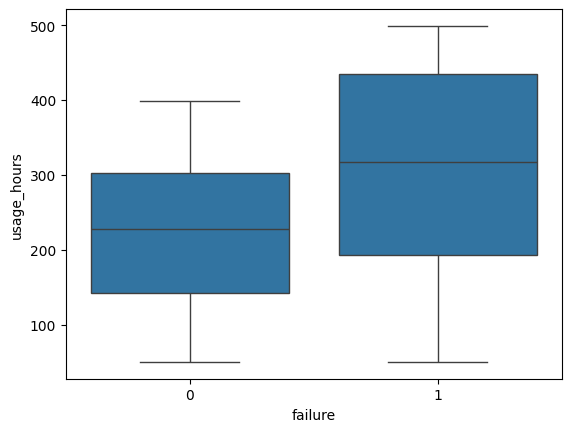

In [20]:
import seaborn as sns             #Higher usage correlates with failure
import matplotlib.pyplot as plt

sns.boxplot(x='failure', y='usage_hours', data=df)
plt.show()

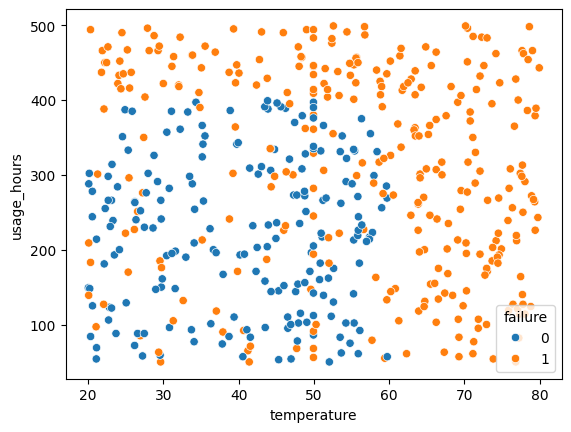

In [21]:
## Temperature Impact
sns.scatterplot(x='temperature', y='usage_hours', hue='failure', data=df)
plt.show()

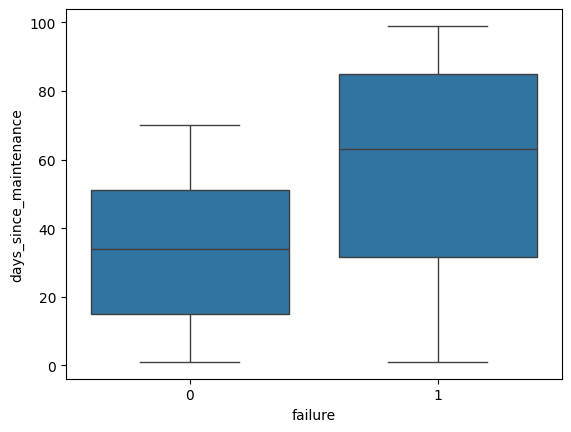

In [22]:
#Maintenance Gap Analysis
sns.boxplot(x='failure', y='days_since_maintenance', data=df)
plt.show()

In [23]:
# Risk Score
df['risk_score'] = (
    0.4 * (df['usage_hours'] / df['usage_hours'].max()) +
    0.3 * (df['days_since_maintenance'] / df['days_since_maintenance'].max()) +
    0.3 * (df['temperature'] / df['temperature'].max())
)

In [24]:
## Categorizing the Risk
def risk_label(score):
    if score > 0.7:
        return "High"
    elif score > 0.4:
        return "Medium"
    else:
        return "Low"

df['risk_level'] = df['risk_score'].apply(risk_label)

## Insight Visualization

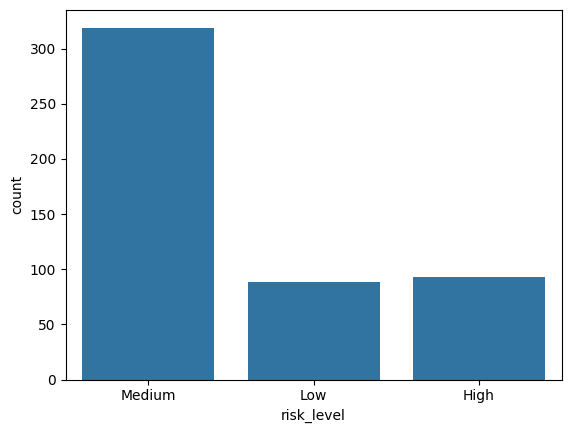

In [26]:
#Risk Level Count
sns.countplot(x='risk_level', data=df)
plt.show()

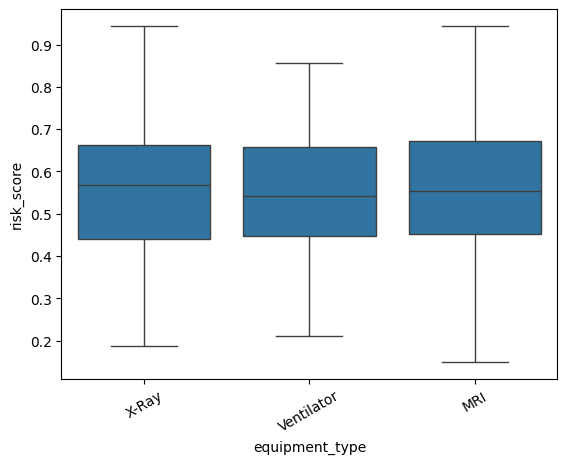

In [27]:
#Equipment Risk Comparision
sns.boxplot(x='equipment_type', y='risk_score', data=df)
plt.xticks(rotation=30)
plt.show()

In [28]:
## High risk Equipment List
df[df['risk_level'] == 'High'].head()

,equipment_id,equipment_type,usage_hours,days_since_maintenance,temperature,load,failure,risk_score,risk_level
17,18,MRI,445,86,49.942011,0.879795,1,0.804693,High
23,24,MRI,494,84,49.025297,0.685460,1,0.834471,High
25,26,Ventilator,476,68,52.390567,0.933107,1,0.784184,High
27,28,X-Ray,317,67,70.491780,0.911238,1,0.721611,High
40,41,Ventilator,435,98,24.665921,0.636837,1,0.738209,High


# Key Observations

### Equipment with higher usage hours consistently shows higher risk levels, indicating overuse is a major stress factor.

### Delayed maintenance strongly correlates with increased failure, suggesting maintenance scheduling is critical, not optional.
### Temperature spikes are linked with high-risk equipment, showing environmental conditions play a role in performance degradation.
### Certain equipment types (like ventilators/MRI depending on your data) cluster in higher risk categories, hinting at uneven workload distribution.
### A small portion of equipment falls into high-risk category but contributes disproportionately to failures, meaning targeted intervention could reduce system breakdowns.